# k-NN for HEP track segment building — from brute force to GPU

The task: after a GNN tags individual detector hits and (optionally) predicts a direction estimate per hit, we want to find for each hit its `k` nearest neighbors in a 5-D feature space, so we can string consistent hits together into short track segments. The feature vector here is

$$\mathbf{x} = (x,\ y,\ z,\ \alpha\,\hat d_x,\ \alpha\,\hat d_y)$$

with three position components and two predicted direction cosines weighted by a scale $\alpha$ that controls how strongly direction influences the metric.

We'll start with brute-force numpy, then add: scipy and sklearn.



In [ ]:
"""
   Do the initial imports - check the machine for additional libs
"""
import numpy as np
import time
from collections import defaultdict
from itertools import product

import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from sklearn.neighbors import KDTree as SKKDTree, BallTree

# Optional libraries
try:
    import faiss
    HAS_FAISS = True
    HAS_FAISS_GPU = faiss.get_num_gpus() > 0
except ImportError:
    HAS_FAISS = False
    HAS_FAISS_GPU = False

try:
    import hnswlib
    HAS_HNSW = True
except ImportError:
    HAS_HNSW = False

""" Progress bars — fall back to a no-op if tqdm isn't installed, try to solve dependencies
    the bars are really cool ;-)
"""
try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(it, *a, **kw):
        return it

print(f"faiss available : {HAS_FAISS}  (GPU: {HAS_FAISS_GPU})")
print(f"hnswlib available: {HAS_HNSW}")


faiss available : False  (GPU: False)
hnswlib available: False


## 1. Synthetic detector hits

We simulate straight tracks emanating from a vertex region. Each track contributes `hits_per_track` hits along its trajectory with small position smearing, and each hit carries a noisy "GNN-predicted" direction (two direction cosines $\hat d_x,\hat d_y$). On top of that we sprinkle random noise hits across the volume.

The direction features are multiplied by `dir_scale` to give them a meaningful weight in the Euclidean metric — without it the position dimensions (which range over ~hundreds) would dominate completely. In practice you'd choose this scale to match your expected position-vs-angle resolution (or just standardize the features).


In [ ]:
"""
   The main place to play with and change!
"""
def generate_tracks(n_tracks=8000, hits_per_track=15, n_noise=400,
                    r_max=100.0, vertex_spread=40.0,
                    sigma_pos=0.3, sigma_dir=0.01,
                    dir_scale=60.0, seed=42):
    """Generate (X, track_id) where X has shape (N, 5).

    Track features: (x, y, z, alpha*dx_pred, alpha*dy_pred)
    track_id == -1 marks noise hits.
    """
    rng = np.random.default_rng(seed)
    feats, tid = [], []
    for t in range(n_tracks):
        vertex = rng.uniform(-vertex_spread, vertex_spread, 3)
        theta = rng.uniform(0.3, np.pi - 0.3)
        phi   = rng.uniform(-np.pi, np.pi)
        d = np.array([np.sin(theta)*np.cos(phi),
                      np.sin(theta)*np.sin(phi),
                      np.cos(theta)])
        for h in range(hits_per_track):
            s = (h + 1) * r_max / hits_per_track
            pos = vertex + s * d + rng.normal(0, sigma_pos, 3)
            dx  = (d[0] + rng.normal(0, sigma_dir)) * dir_scale
            dy  = (d[1] + rng.normal(0, sigma_dir)) * dir_scale
            feats.append([*pos, dx, dy])
            tid.append(t)
    for _ in range(n_noise):
        pos = rng.uniform(-150, 150, 3)
        ct = rng.uniform(-1, 1); ph = rng.uniform(-np.pi, np.pi)
        st = np.sqrt(1 - ct**2)
        feats.append([*pos,
                      st * np.cos(ph) * dir_scale,
                      st * np.sin(ph) * dir_scale])
        tid.append(-1)
    X = np.array(feats, dtype=np.float32)
    y = np.array(tid)
    perm = rng.permutation(len(X))
    return X[perm], y[perm]


X_demo, y_demo = generate_tracks()
print(f"X shape: {X_demo.shape}  dtype: {X_demo.dtype}")
print(f"track hits: {(y_demo >= 0).sum()}   noise hits: {(y_demo < 0).sum()}")


X shape: (120400, 5)  dtype: float32
track hits: 120000   noise hits: 400


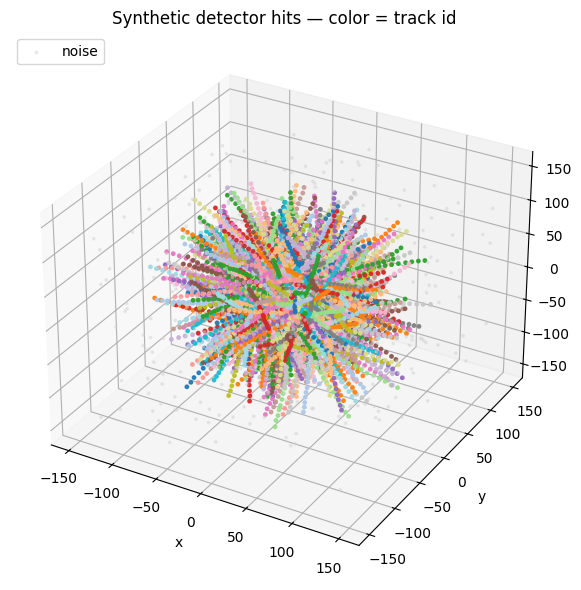

In [ ]:
"""
   Wizualizacja - może być ulepszona... np. projekcja na 2D? Itp.
"""
# 3-D look at the data (positions only)
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
mask = y_demo >= 0
ax.scatter(X_demo[~mask, 0], X_demo[~mask, 1], X_demo[~mask, 2],
           s=3, c='lightgray', alpha=0.4, label='noise')
sc = ax.scatter(X_demo[mask, 0], X_demo[mask, 1], X_demo[mask, 2],
                s=6, c=y_demo[mask], cmap='tab20', alpha=0.9)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('Synthetic detector hits: color = track id')
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()


## 2. Benchmark setup

For each method we want the same answer: for every hit `i`, the indices of its `k` nearest neighbors (excluding itself) in 5-D Euclidean space. We measure wall-clock time including any index build, since for a static event the build is part of the cost. The helper below times each method with a warm-up plus a few runs and returns the minimum (more stable than the mean against system jitter).


In [ ]:
"""
   Funkcja ściągnięta z zajęć o dekoratorach, też można zmienić
"""
def time_method(fn, n_runs=3, warmup=1, label=None):
    """Run `fn` and return (min_time_seconds, result_from_last_run).

    If `label` is given, prints incremental progress so you can see what's
    actually running (warmup, then each timed run).
    """
    if label:
        print(f"  [{label}] warmup...", end='', flush=True)
    for _ in range(warmup):
        out = fn()
    if label:
        print(" done.", end='', flush=True)
    times = []
    for i in range(n_runs):
        if label:
            print(f"  run {i+1}/{n_runs}...", end='', flush=True)
        t0 = time.perf_counter()
        out = fn()
        dt = time.perf_counter() - t0
        times.append(dt)
        if label:
            print(f" {dt*1000:.1f}ms", end='', flush=True)
    if label:
        print(f"   --> best {min(times)*1000:.1f}ms")
    return min(times), out


K = 5   # neighborhood size for the demo


## 3. Method 1 — Numpy brute force (with the GEMM trick)

The standard way to compute all pairwise squared distances without writing a Python loop is

$$\|a-b\|^2 = \|a\|^2 + \|b\|^2 - 2\,a\!\cdot\! b$$

The cross-term is a single matrix multiply, which BLAS handles at near-peak throughput. Memory is the bottleneck — the full $N\times N$ distance matrix is $O(N^2)$, so for large $N$ we chunk the query rows.


In [ ]:
def knn_numpy(X, k, chunk=2048, progress=False):
    N = X.shape[0]
    sq = np.sum(X * X, axis=1)
    idx  = np.empty((N, k), dtype=np.int64)
    dist = np.empty((N, k), dtype=np.float32)
    starts = range(0, N, chunk)
    if progress:
        starts = tqdm(list(starts), desc="numpy chunks", leave=False)
    for s in starts:
        e = min(s + chunk, N)
        # squared distances from rows [s:e] to all rows
        D = sq[s:e, None] + sq[None, :] - 2.0 * (X[s:e] @ X.T)
        D = np.maximum(D, 0.0)
        # exclude self
        rows = np.arange(s, e)
        D[rows - s, rows] = np.inf
        # partial sort: top-k indices, then sort within
        part = np.argpartition(D, k, axis=1)[:, :k]
        for i in range(e - s):
            order = np.argsort(D[i, part[i]])
            idx[s+i]  = part[i, order]
            dist[s+i] = np.sqrt(D[i, part[i, order]])
    return dist, idx


t_np, (d_np, i_np) = time_method(
    lambda: knn_numpy(X_demo, K, progress=True),
    label="numpy brute force")


  [numpy brute force] warmup...

numpy chunks:   0%|          | 0/59 [00:00<?, ?it/s]

 done.  run 1/3...

numpy chunks:   0%|          | 0/59 [00:00<?, ?it/s]

 276168.2ms  run 2/3...

numpy chunks:   0%|          | 0/59 [00:00<?, ?it/s]

 282962.8ms  run 3/3...

numpy chunks:   0%|          | 0/59 [00:00<?, ?it/s]

 261894.1ms   --> best 261894.1ms


## 4. Method 2 — scipy cKDTree

A KD-tree partitions space with axis-aligned splits. In our 5 dimensions there's still plenty of pruning to be had. `cKDTree` is a C implementation in scipy with parallel query via `workers=-1`.


In [ ]:
def knn_scipy(X, k):
    tree = cKDTree(X)
    d, i = tree.query(X, k=k+1, workers=-1)   # k+1 to skip self
    return d[:, 1:].astype(np.float32), i[:, 1:]


t_sp, (d_sp, i_sp) = time_method(lambda: knn_scipy(X_demo, K),
                                 label="scipy cKDTree")
print(f"  speedup vs numpy: {t_np/t_sp:.1f}x")


## 5. Method 3 — sklearn KDTree and BallTree

Same idea, different implementation. BallTree partitions with nested hyperspheres instead of axis-aligned boxes; it tends to do better than KDTree as dimension grows, though in 5-D both are fast.


In [ ]:
def knn_sklearn_kd(X, k):
    tree = SKKDTree(X)
    d, i = tree.query(X, k=k+1)
    return d[:, 1:].astype(np.float32), i[:, 1:]


def knn_sklearn_ball(X, k):
    tree = BallTree(X)
    d, i = tree.query(X, k=k+1)
    return d[:, 1:].astype(np.float32), i[:, 1:]


t_skd, (d_skd, i_skd) = time_method(lambda: knn_sklearn_kd(X_demo, K),
                                    label="sklearn KDTree")
t_sbt, (d_sbt, i_sbt) = time_method(lambda: knn_sklearn_ball(X_demo, K),
                                    label="sklearn BallTree")
